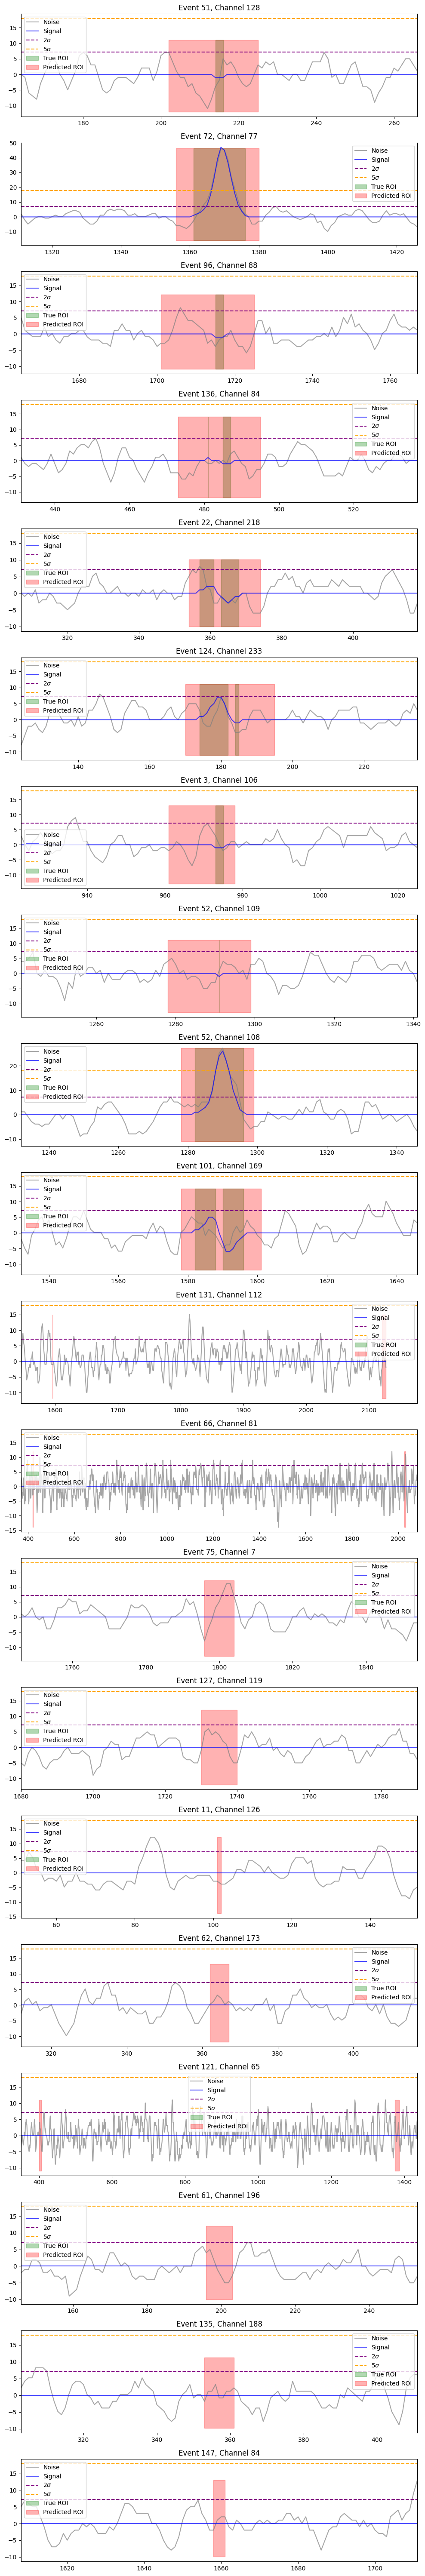

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Load memmap files
noise_memmap = np.memmap("noise.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
signal_memmap = np.memmap("signal.raw", dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
roi_memmap = np.load("roi.npy")  # True ROI
roi_pred = np.load("/scratch/7DayLifetime/mking/03_13_2025_1/roi_pred_CNN.npy")  # Predicted ROI from traditional algorithm

# Extract TPC 0 Plane Z
#noise_data = noise_memmap[:, 800:1040, :]
#signal_data = signal_memmap[:, 800:1040, :]
#roi_data = roi_memmap[:, 800:1040, :]
#Just get training data
noise_data = noise_memmap[850:1000, 800:1040, :]
signal_data = signal_memmap[850:1000, 800:1040, :]
roi_data = roi_memmap[850:1000, 800:1040, :]
roi_pred_data = roi_pred #[:, 800:1040, :] -- roi_pred is already just TPC 0 Plane Z

# Compute noise statistics (mean and standard deviation)
noise_mean = np.mean(noise_data - signal_data)
noise_std = np.std(noise_data - signal_data)

# Find indices where true ROI is nonzero
valid_indices = np.argwhere(roi_data.sum(axis=2) > 0)  # Get (event_idx, ch_idx) where true ROI exists

# Select a few random waveforms from the valid ones
num_samples = 10
selected_indices = random.sample(list(valid_indices), min(num_samples, len(valid_indices)))

# Also grab some for where the pred ROI is nonzero
valid_indices_pred = np.argwhere(roi_pred_data.sum(axis=2) > 0)  # Get (event_idx, ch_idx) where true ROI exists
selected_indices += random.sample(list(valid_indices_pred), min(num_samples, len(valid_indices)))

fig, axes = plt.subplots(len(selected_indices), 1, figsize=(10, 3 * len(selected_indices)))

for i, (event_idx, ch_idx) in enumerate(selected_indices):
    noise_waveform = noise_data[event_idx, ch_idx, :]
    signal_waveform = signal_data[event_idx, ch_idx, :]
    true_roi = roi_data[event_idx, ch_idx, :]
    predicted_roi = roi_pred_data[event_idx, ch_idx, :]

    ax = axes[i] if len(selected_indices) > 1 else axes
    if (i<10):
        ax.set_xlim(np.where(true_roi)[0][0] -50, np.where(true_roi)[0][-1] +50)
    if (i>=10):
        ax.set_xlim(np.where(predicted_roi)[0][0] -50, np.where(predicted_roi)[0][-1] +50)
    ax.plot(noise_waveform, color='gray', alpha=0.7, label="Noise")
    ax.plot(signal_waveform, color='blue', alpha=0.7, label="Signal")

    #Add horiztonal lines for 2 sigma and 5 sigma
    ax.axhline(noise_mean + 2* noise_std, color='purple', linestyle='dashed', label=r'$2\sigma$')
    ax.axhline(noise_mean + 5* noise_std, color='orange', linestyle='dashed', label=r'$5\sigma$')
    
    # Shade True ROI
    ax.fill_between(range(len(true_roi)), min(noise_waveform), max(noise_waveform),
                    where=true_roi > 0, color='green', alpha=0.3, label="True ROI")
    
    # Shade Predicted ROI
    ax.fill_between(range(len(predicted_roi)), min(noise_waveform), max(noise_waveform),
                    where=predicted_roi > 0, color='red', alpha=0.3, label="Predicted ROI")
    
    ax.set_title(f"Event {event_idx}, Channel {ch_idx}")
    ax.legend()

plt.tight_layout()
plt.show()

55
150
55
49


/tmp/ipykernel_2135/3884296906.py:15: RuntimeWarning: invalid value encountered in divide
  Ratio = np.divide(Pred_Ar39_Fraction,True_Ar39_Fraction)


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0., 46.]),
 array([0.75      , 0.75833333, 0.76666667, 0.775     , 0.78333333,
        0.79166667, 0.8       , 0.80833333, 0.81666667, 0.825     ,
        0.83333333, 0.84166667, 0.85      , 0.85833333, 0.86666667,
        0.875     , 0.88333333, 0.89166667, 0.9       , 0.90833333,
        0.91666667, 0.925     , 0.93333333, 0.94166667, 0.95      ,
        0.95833333, 0.96666667, 0.975     , 0.98333333, 0.99166667,
        1.        ]),
 <BarContainer object of 30 artists>)

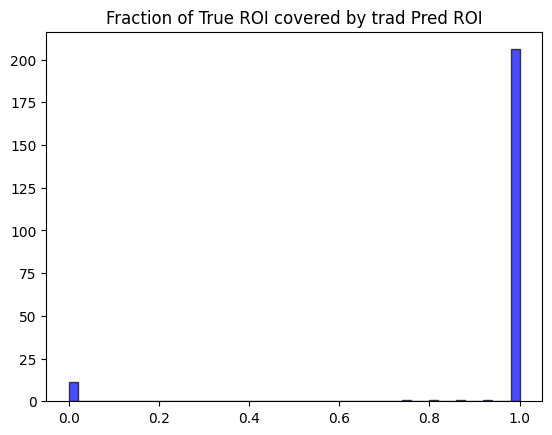

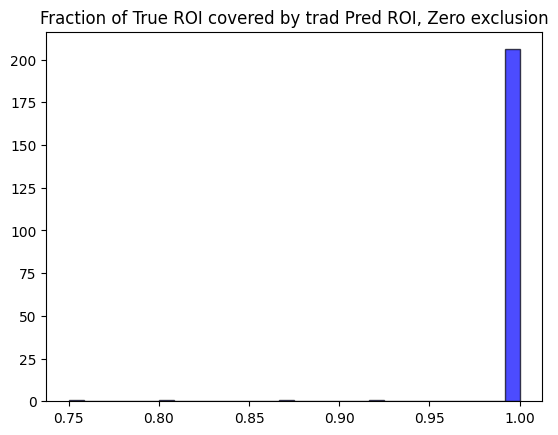

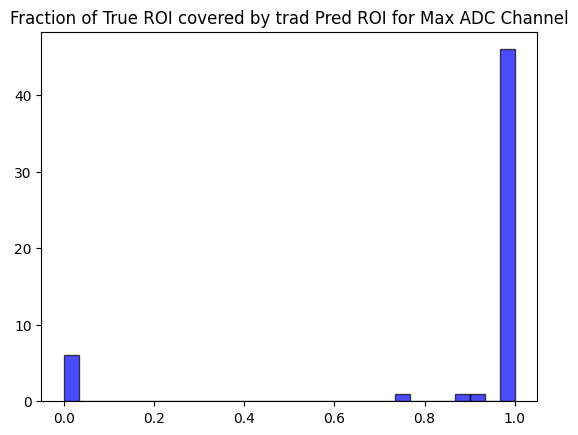

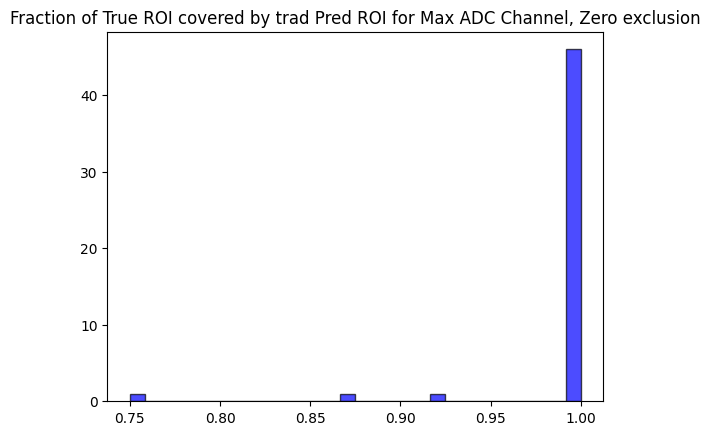

In [3]:
### Efficiency plots ###

#In how many events with a true ROI do we identify any predicted ROI?
True_Ar39_Events = np.any(roi_data,axis=(1,2))
Pred_Ar39_Events = np.any(roi_pred_data,axis=(1,2))

countTrue = np.sum(True_Ar39_Events)
countPred = np.sum(Pred_Ar39_Events)

print(countTrue)
print(countPred)

#Ok... now plot the distributions of the fractions of the true ROI covered
True_Ar39_Fraction = np.sum(roi_data,axis=2)
Pred_Ar39_Fraction = np.sum(np.logical_and(roi_pred_data,roi_data),axis=2) #efficiency

Ratio = np.divide(Pred_Ar39_Fraction,True_Ar39_Fraction)
Ratio_flatten = Ratio.flatten()
Ratio_sanitized = Ratio_flatten[np.isfinite(Ratio_flatten)]

#Let's plot the fractions of ROI covered just for the MaxADCChannel
#signal_data = signal_memmap[:, 800:1040, :]
max_adc_per_channel = np.max(signal_data, axis=2)

# Find the index of the channel with the maximum ADC value for each event (axis 1)
max_adc_channels = np.argmax(max_adc_per_channel, axis=1)

# max_adc_channels now holds the index of the channel with the max ADC value for each event
#print(max_adc_channels)

Ratio_Best = []
for iEvent in range(150):
    if np.max(signal_data[iEvent]) > 0:
        Ratio_Best.append(Ratio[iEvent][max_adc_channels[iEvent]])
Ratio_Best = np.array(Ratio_Best)
print(len(Ratio_Best))
print(len(Ratio_Best[Ratio_Best > 0]))

plt.figure()
plt.title("Fraction of True ROI covered by trad Pred ROI")
plt.hist(Ratio_sanitized, bins=50, alpha=0.7, color='b', edgecolor='black')

plt.figure()
plt.title("Fraction of True ROI covered by trad Pred ROI, Zero exclusion")
plt.hist(Ratio_sanitized[Ratio_sanitized > 0], bins=30, alpha=0.7, color='b', edgecolor='black')

plt.figure()
plt.title("Fraction of True ROI covered by trad Pred ROI for Max ADC Channel")
plt.hist(Ratio_Best, bins=30, alpha=0.7, color='b', edgecolor='black')

plt.figure()
plt.title("Fraction of True ROI covered by trad Pred ROI for Max ADC Channel, Zero exclusion")
plt.hist(Ratio_Best[Ratio_Best > 0], bins=30, alpha=0.7, color='b', edgecolor='black')

55
150
55
49


/tmp/ipykernel_2135/241109891.py:17: RuntimeWarning: invalid value encountered in divide
  Ratio = np.divide(True_Ar39_Fraction,Pred_Ar39_Fraction)


(array([2., 0., 1., 0., 3., 3., 0., 2., 0., 1., 3., 1., 1., 1., 1., 8., 8.,
        5., 3., 3., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1.]),
 array([0.2962963 , 0.31975309, 0.34320988, 0.36666667, 0.39012346,
        0.41358025, 0.43703704, 0.46049383, 0.48395062, 0.50740741,
        0.5308642 , 0.55432099, 0.57777778, 0.60123457, 0.62469136,
        0.64814815, 0.67160494, 0.69506173, 0.71851852, 0.74197531,
        0.7654321 , 0.78888889, 0.81234568, 0.83580247, 0.85925926,
        0.88271605, 0.90617284, 0.92962963, 0.95308642, 0.97654321,
        1.        ]),
 <BarContainer object of 30 artists>)

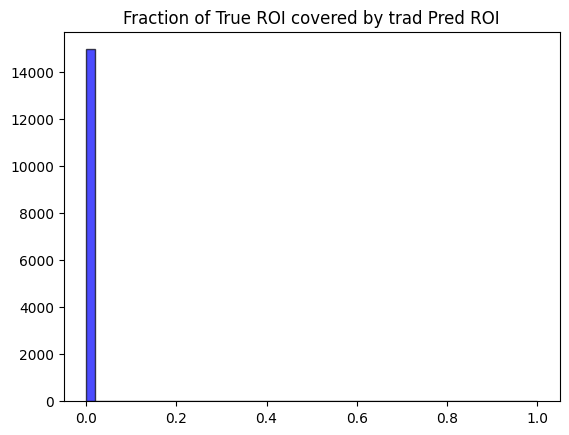

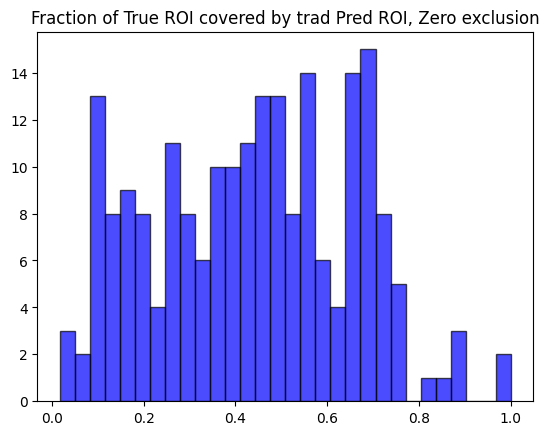

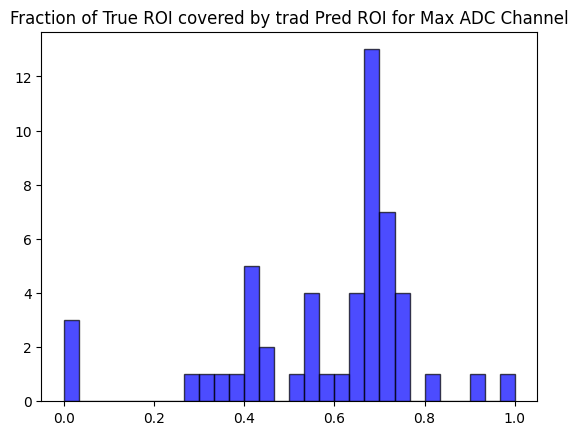

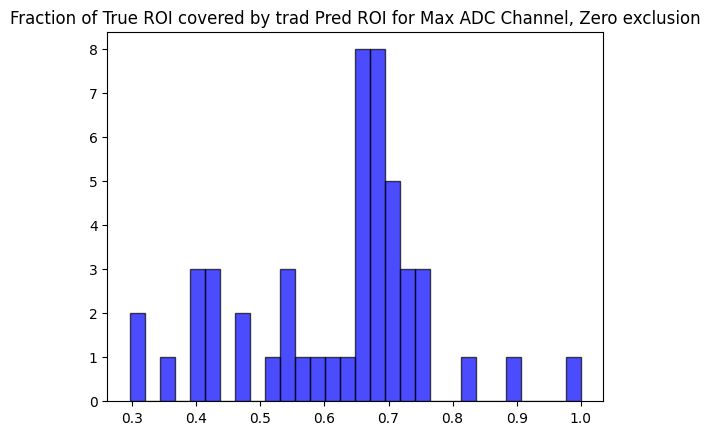

In [8]:
### Purity plots ###

#In how many events with a true ROI do we identify any predicted ROI?
True_Ar39_Events = np.any(roi_data,axis=(1,2))
Pred_Ar39_Events = np.any(roi_pred_data,axis=(1,2))

countTrue = np.sum(True_Ar39_Events)
countPred = np.sum(Pred_Ar39_Events)

print(countTrue)
print(countPred)

#Ok... now plot the distributions of the purity for each channel in the test data
True_Ar39_Fraction = np.sum(np.logical_and(roi_pred_data,roi_data),axis=2) #purity
Pred_Ar39_Fraction = np.sum(roi_pred_data,axis=2) 

Ratio = np.divide(True_Ar39_Fraction,Pred_Ar39_Fraction)
Ratio_flatten = Ratio.flatten()
Ratio_sanitized = Ratio_flatten[np.isfinite(Ratio_flatten)]

#Let's plot the fractions of ROI covered just for the MaxADCChannel
#signal_data = signal_memmap[:, 800:1040, :]
max_adc_per_channel = np.max(signal_data, axis=2)

# Find the index of the channel with the maximum ADC value for each event (axis 1)
max_adc_channels = np.argmax(max_adc_per_channel, axis=1)

# max_adc_channels now holds the index of the channel with the max ADC value for each event
#print(max_adc_channels)

Ratio_Best = []
for iEvent in range(150):
    if np.max(signal_data[iEvent]) > 0:
        Ratio_Best.append(Ratio[iEvent][max_adc_channels[iEvent]])
Ratio_Best = np.array(Ratio_Best)
print(len(Ratio_Best))
print(len(Ratio_Best[Ratio_Best > 0]))

plt.figure()
plt.title("Fraction of Pred ROI covered by True ROI")
plt.hist(Ratio_sanitized, bins=50, alpha=0.7, color='b', edgecolor='black')

plt.figure()
plt.title("Fraction of Pred ROI covered by True ROI, Zero exclusion")
plt.hist(Ratio_sanitized[Ratio_sanitized > 0], bins=30, alpha=0.7, color='b', edgecolor='black')

plt.figure()
plt.title("Fraction of Pred ROI covered by True ROI for Max ADC Channel")
plt.hist(Ratio_Best, bins=30, alpha=0.7, color='b', edgecolor='black')

plt.figure()
plt.title("Fraction of Pred ROI covered by True ROI for Max ADC Channel, Zero exclusion")
plt.hist(Ratio_Best[Ratio_Best > 0], bins=30, alpha=0.7, color='b', edgecolor='black')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load the traditional predicted ROI and noise+signal data
roi_path = 'roi_pred_trad.npy'
noise_signal_path = 'noise.raw'

# Load ROI (shape: (1000, 240, 2128))
roi = np.load(roi_path)

# Load noise+signal using memmap (shape: (1000, 240, 2128))
noise_memmap = np.memmap(noise_signal_path, dtype=np.float32, mode='r', shape=(1000, 1280, 2128))
noise_signal = noise_memmap[:, 800:1040, :]

# Validate that both arrays have the same shape
assert roi.shape == noise_signal.shape, "Shape mismatch between ROI and noise+signal arrays."

# Compute the weighted integral for each event
# Multiply noise+signal by the ROI mask and sum over the wire (axis=2) and channels (axis=1)
weighted_integrals = np.sum(noise_signal * roi, axis=(1, 2))

weighted_integrals=weighted_integrals[weighted_integrals>0]

scale_factor = 170/333 #keV/ADC*timetick, matching peak of Ar39 spectrum to peak of integral spectrum
weighted_integrals *= scale_factor

min_energy = np.min(weighted_integrals)

# Create a presentation-quality histogram
plt.figure(figsize=(10, 6))
plt.hist(weighted_integrals, bins=50, color='royalblue', edgecolor='black', alpha=0.75)
plt.axvline(min_energy, color='g', linestyle='solid', label='Minimum: '+str(round(min_energy))+' keV')

# Set axis labels and title
plt.xlabel('Energy [keV]', fontsize=14)
plt.ylabel('Event Count', fontsize=14)
#plt.title('Integral Over Traditional Predicted ROI of Noise + Signal', fontsize=16)
plt.title('Energy Via Integral Over Traditional Predicted ROI of Simulated Noise + Signal', fontsize=16)

# Improve tick formatting
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
plt.tick_params(axis='both', which='major', labelsize=12)

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Display the histogram
plt.legend()
plt.tight_layout()
plt.show()